In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
from pathlib import Path
import os

ZIP_PATH = "/content/drive/MyDrive/Pod_disease_classification_dataset.zip"
EXTRACT_DIR = Path("/content/cardamom_pod_disease__dataset")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted to:", EXTRACT_DIR)

for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(str(EXTRACT_DIR), "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{Path(root).name}/")
    if level >= 3:
        continue

Dataset extracted to: /content/cardamom_pod_disease__dataset
cardamom_pod_disease__dataset/
  classification_dataset/
    test/
      cardamom_thrips/
      capsule_borer/
    train/
      cardamom_thrips/
      capsule_borer/
    val/
      cardamom_thrips/
      capsule_borer/


In [ ]:
from pathlib import Path

possible_paths = list(EXTRACT_DIR.rglob("classification_dataset"))

if len(possible_paths) == 0:
    raise FileNotFoundError("classification_dataset folder not found inside zip.")

DATASET_DIR = possible_paths[0]

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

print("DATASET_DIR:", DATASET_DIR)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)

DATASET_DIR: /content/cardamom_pod_disease__dataset/classification_dataset
TRAIN_DIR: /content/cardamom_pod_disease__dataset/classification_dataset/train
VAL_DIR: /content/cardamom_pod_disease__dataset/classification_dataset/val
TEST_DIR: /content/cardamom_pod_disease__dataset/classification_dataset/test


In [ ]:
from pathlib import Path

classes = ["capsule_borer", "cardamom_thrips"]
valid_exts = [".jpg", ".jpeg", ".png", ".webp"]

def count_images(folder):
    return len([
        p for p in Path(folder).rglob("*")
        if p.suffix.lower() in valid_exts
    ])

for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(f"\n{split_dir.name.upper()}")
    for cls in classes:
        cls_path = split_dir / cls
        print(cls, ":", count_images(cls_path))


TRAIN
capsule_borer : 924
cardamom_thrips : 1002

VAL
capsule_borer : 198
cardamom_thrips : 214

TEST
capsule_borer : 199
cardamom_thrips : 216


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
import os

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_STAGE_1 = 15
EPOCHS_STAGE_2 = 20

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 1926 files belonging to 2 classes.
Found 412 files belonging to 2 classes.
Found 415 files belonging to 2 classes.
Classes: ['capsule_borer', 'cardamom_thrips']
Number of classes: 2


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

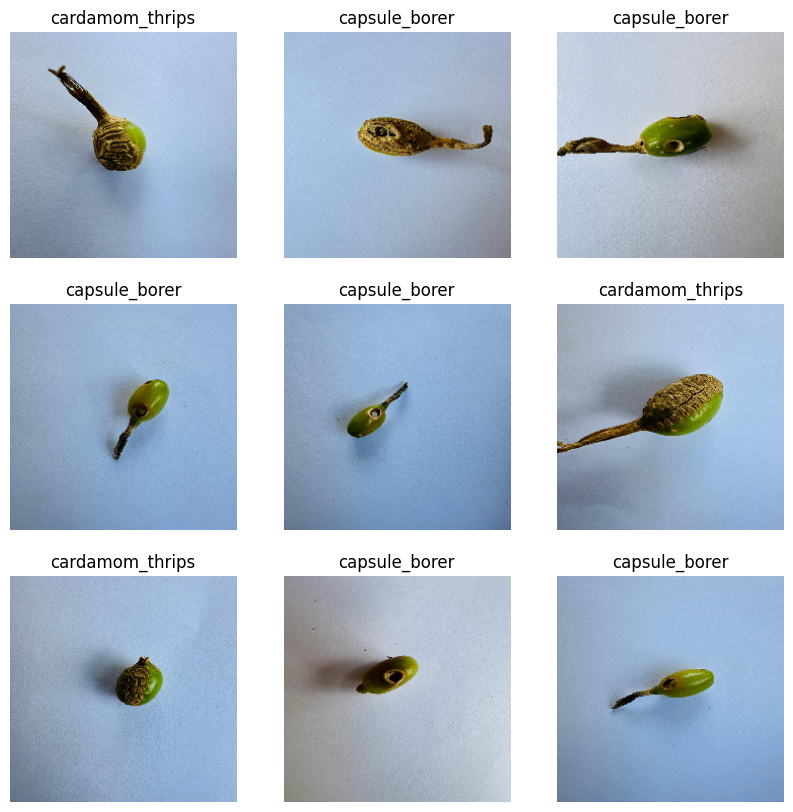

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_index = np.argmax(labels[i].numpy())
        plt.title(class_names[label_index])
        plt.axis("off")

plt.show()

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.15),
], name="data_augmentation")

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
MODEL_DIR = Path("/content/drive/MyDrive/Cardamom_pod_disease/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "best_effnetb0_cardamom_2class.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
history_stage_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_1,
    callbacks=callbacks
)

Epoch 1/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.7736 - loss: 0.4672
Epoch 1: val_accuracy improved from None to 0.97330, saving model to /content/drive/MyDrive/Cardamom_pod_disease/models/best_effnetb0_cardamom_2class.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Cardamom_pod_disease/models/best_effnetb0_cardamom_2class.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 36s 314ms/step - accuracy: 0.8993 - loss: 0.2821 - val_accuracy: 0.9733 - val_loss: 0.1234 - learning_rate: 0.0010
Epoch 2/15
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9761 - loss: 0.1147
Epoch 2: val_accuracy improved from 0.97330 to 0.98058, saving model to /content/drive/MyDrive/Cardamom_pod_disease/models/best_effnetb0_cardamom_2class.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Cardamom_pod_disease/models/best_effnetb0_cardamom_2class.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 16s 269ms/step - accuracy: 0.9803 - loss: 0.0973 - val_accuracy: 0.9806 - val_loss: 0.0927 - learnin

In [ ]:
base_model.trainable = True

# Freeze early layers, fine-tune only later layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 1,498,722 (5.72 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

In [ ]:
history_stage_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_2,
    callbacks=callbacks
)

Epoch 1/20
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9796 - loss: 0.0721
Epoch 1: val_accuracy improved from 0.98786 to 0.99029, saving model to /content/drive/MyDrive/Cardamom_pod_disease/models/best_effnetb0_cardamom_2class.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Cardamom_pod_disease/models/best_effnetb0_cardamom_2class.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 34s 312ms/step - accuracy: 0.9808 - loss: 0.0704 - val_accuracy: 0.9903 - val_loss: 0.0290 - learning_rate: 1.0000e-05
Epoch 2/20
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9829 - loss: 0.0647
Epoch 2: val_accuracy did not improve from 0.99029
61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 314ms/step - accuracy: 0.9808 - loss: 0.0655 - val_accuracy: 0.9903 - val_loss: 0.0329 - learning_rate: 1.0000e-05
Epoch 3/20
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9859 - loss: 0.0435
Epoch 3: val_accuracy did not improve from 0.99029

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.99999992421

In [ ]:
best_model = keras.models.load_model(BEST_MODEL_PATH)

test_loss, test_accuracy = best_model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 235ms/step - accuracy: 0.9880 - loss: 0.0220
Test Loss: 0.0220
Test Accuracy: 0.9880


In [ ]:
# building extra TFLite model and normal keras

import tensorflow as tf
from pathlib import Path

MODEL_DIR = Path("/content/drive/MyDrive/Cardamom_pod_disease/models")

# Load the exact best Keras model
best_model_path = MODEL_DIR / "best_effnetb0_cardamom_2class.keras"
best_model = tf.keras.models.load_model(best_model_path)

# Convert WITHOUT optimization first
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

tflite_path = MODEL_DIR / "cardamom_pod_disease_effnetb0_float32.tflite"

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("Saved Float32 TFLite model:", tflite_path)

Saved artifact at '/tmp/tmpdm411x0f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140287164438608: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  140287164445712: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  140286910926096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140286910926480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140286910925328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140286910927632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140286910928208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140286910927056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140286910925712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140286910928016: TensorSpec(shape=(), dtype=tf.resource, name=Non

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

                 precision    recall  f1-score   support

  capsule_borer       0.99      0.98      0.99       199
cardamom_thrips       0.98      1.00      0.99       216

       accuracy                           0.99       415
      macro avg       0.99      0.99      0.99       415
   weighted avg       0.99      0.99      0.99       415



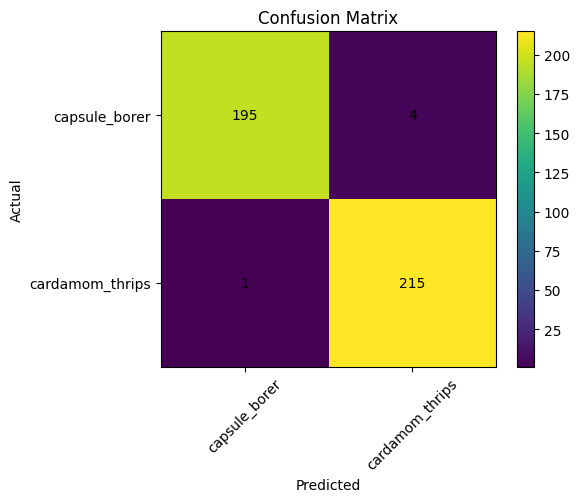

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

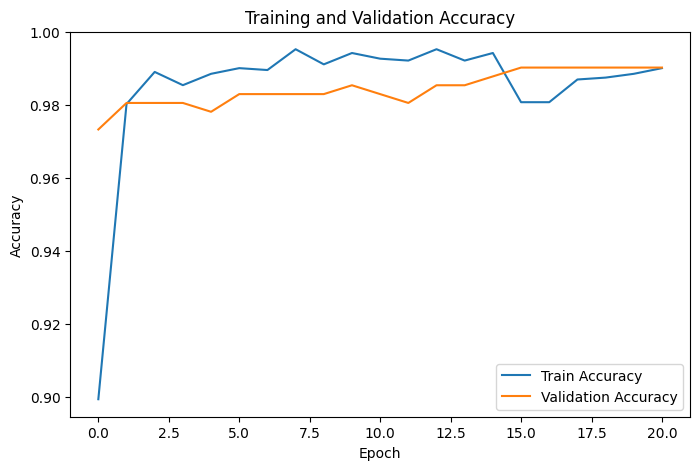

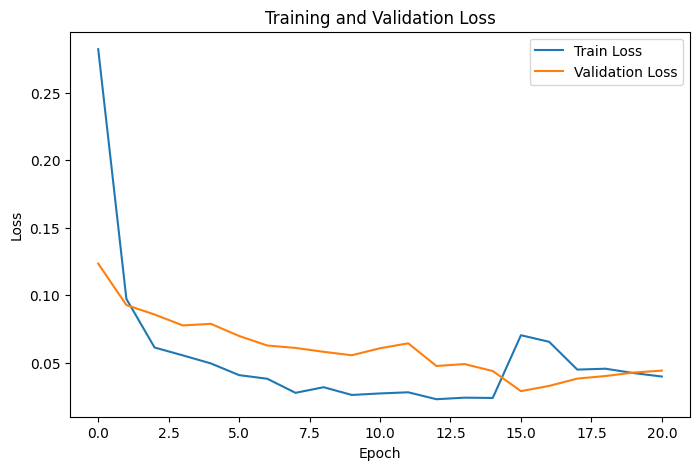

In [ ]:
def plot_history(histories):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for h in histories:
        acc += h.history["accuracy"]
        val_acc += h.history["val_accuracy"]
        loss += h.history["loss"]
        val_loss += h.history["val_loss"]

    plt.figure(figsize=(8, 5))
    plt.plot(acc, label="Train Accuracy")
    plt.plot(val_acc, label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(loss, label="Train Loss")
    plt.plot(val_loss, label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history([history_stage_1, history_stage_2])

Saving p4-6_cardamon_page2_image1.jpg to p4-6_cardamon_page2_image1 (1).jpg


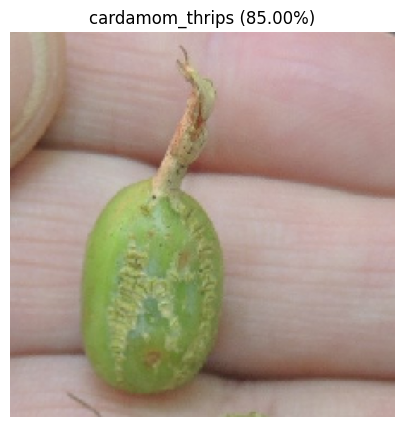

Prediction: cardamom_thrips
Confidence: 85.0 %
All probabilities:
capsule_borer: 15.00%
cardamom_thrips: 85.00%


In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

uploaded = files.upload()

def predict_single_image(image_path, model):
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_batch, verbose=0)[0]
    pred_index = np.argmax(preds)
    pred_class = class_names[pred_index]
    confidence = preds[pred_index]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{pred_class} ({confidence * 100:.2f}%)")
    plt.show()

    print("Prediction:", pred_class)
    print("Confidence:", round(float(confidence) * 100, 2), "%")
    print("All probabilities:")
    for cls, prob in zip(class_names, preds):
        print(f"{cls}: {prob * 100:.2f}%")

for filename in uploaded.keys():
    predict_single_image(filename, best_model)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

IMG_SIZE = (224, 224)

image_path = "/content/p4-6_cardamon_page2_image1.jpg"  #

img = load_img(image_path, target_size=IMG_SIZE)
img_array = img_to_array(img).astype("float32")
img_batch = np.expand_dims(img_array, axis=0)

# Keras prediction
keras_preds = best_model.predict(img_batch, verbose=0)[0]

print("KERAS prediction:")
for cls, prob in zip(class_names, keras_preds):
    print(f"{cls}: {prob * 100:.2f}%")

# TFLite prediction
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("TFLite input details:", input_details)
print("TFLite output details:", output_details)

interpreter.set_tensor(input_details[0]["index"], img_batch.astype(np.float32))
interpreter.invoke()

tflite_preds = interpreter.get_tensor(output_details[0]["index"])[0]

print("\nTFLITE prediction:")
for cls, prob in zip(class_names, tflite_preds):
    print(f"{cls}: {prob * 100:.2f}%")

KERAS prediction:
capsule_borer: 15.00%
cardamom_thrips: 85.00%
TFLite input details: [{'name': 'serving_default_input_layer_1:0', 'index': 0, 'shape': array([  1, 224, 224,   3], dtype=int32), 'shape_signature': array([ -1, 224, 224,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
TFLite output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 486, 'shape': array([1, 2], dtype=int32), 'shape_signature': array([-1,  2], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

TFLITE prediction:
capsule_borer: 15.00%
cardamom_thrips: 85.00%


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
import json

FINAL_MODEL_PATH = MODEL_DIR / "final_cardamom_pod_disease_effnetb0.keras"
best_model.save(FINAL_MODEL_PATH)

CLASS_NAMES_PATH = MODEL_DIR / "class_names.json"

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(class_names, f)

print("Saved model:", FINAL_MODEL_PATH)
print("Saved class names:", CLASS_NAMES_PATH)

Saved model: /content/drive/MyDrive/Cardamom_pod_disease/models/final_cardamom_pod_disease_effnetb0.keras
Saved class names: /content/drive/MyDrive/Cardamom_pod_disease/models/class_names.json
